In [1]:
import os
import sys
if '../' not in sys.path:
    sys.path.append('../')

import numpy as np
import matplotlib.pyplot as plt

from scipy.interpolate import interp1d, UnivariateSpline
from scipy.integrate import quad

from mcp_boltzmann.gstar import *

/Users/duncan/src/mcp_boltzmann/notebooks/../mcp_boltzmann/gstar.py:14: RuntimeWarning: overflow encountered in exp
  return u**2*np.sqrt(u**2-z**2)/(np.exp(u) + 1)
/Users/duncan/src/mcp_boltzmann/notebooks/../mcp_boltzmann/gstar.py:17: RuntimeWarning: overflow encountered in exp
  return (u**2 - z**2)**(1.5)/(np.exp(u) + 1)


## Plot g* for energy and pressure densities, with and without neutrinos

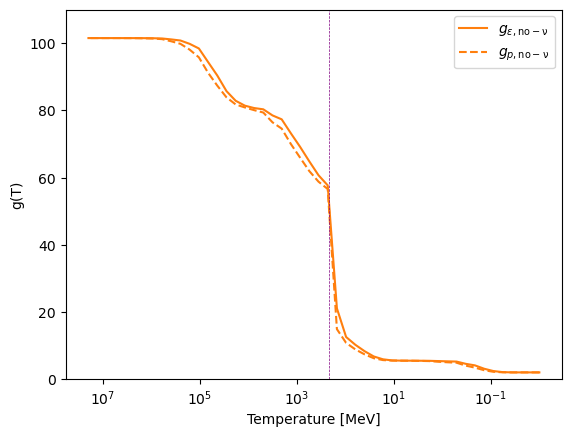

In [25]:
LQCD = 214
T = np.geomspace(1e-2, 2e7)
# plt.plot(T, g_E, color='C0', label=r'$g_{\epsilon}$')
# plt.plot(T, g_P, color='C0', linestyle='dashed', label=r'$g_{p}$')
plt.plot(T, gstar_E_EM(T), color='C1', label=r'$g_{\epsilon, \rm{no-}\nu}$')
plt.plot(T, gstar_P_EM(T), color='C1', linestyle='dashed', label=r'$g_{p, \rm{no-}\nu}$')
plt.axvline(LQCD, color='purple', linestyle='dashed', linewidth=0.5)

plt.xlabel('Temperature [MeV]')
plt.ylabel('g(T)')

plt.xscale('log')
plt.gca().invert_xaxis()

plt.ylim(0, 110)

plt.legend()
plt.show()

## Derivatve of g* for Energy density

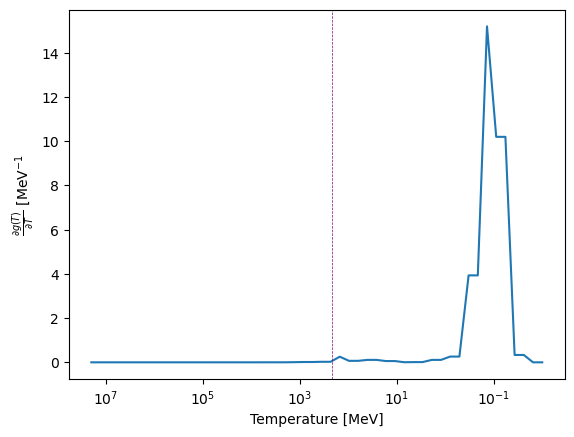

In [30]:
plt.plot(T, d_gstar_E_EM_dT(T))
plt.axvline(LQCD, color='purple', linestyle='dashed', linewidth=0.5)

plt.gca().invert_xaxis()

plt.xscale('log')
plt.ylabel(r'$\frac{\partial g(T)}{\partial T}$ [MeV$^{-1}$')
plt.xlabel('Temperature [MeV]')
plt.show()

### EM Plasma Energy Density

In [36]:
def rho_EM(T):
    return (np.pi**2/30)*gstar_E_EM(T)*T**4

def drho_EM_dT(T):
    return 4*(np.pi**2/30)*gstar_E_EM(T)*T**3 + (np.pi**2/30)*d_gstar_E_EM_dT(T)*T**4

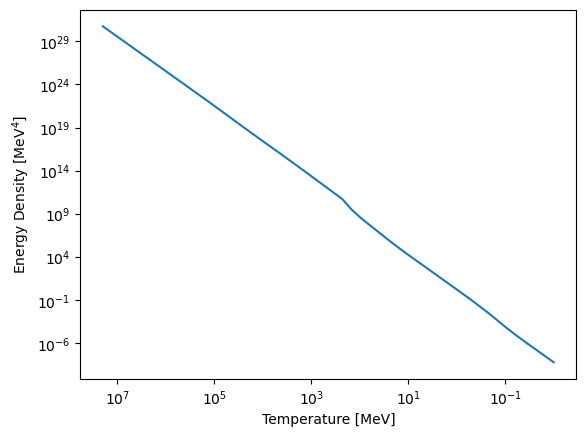

In [37]:
plt.plot(T, rho_EM(T))

plt.xlabel('Temperature [MeV]')
plt.ylabel(r'Energy Density [MeV$^4$]')

plt.yscale('log')
plt.xscale('log')

plt.gca().invert_xaxis()

plt.show()

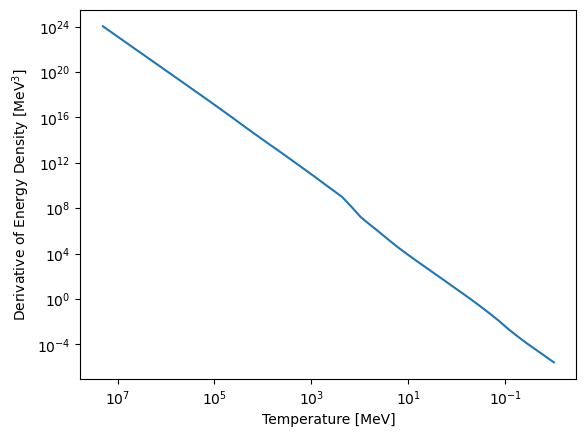

In [39]:
plt.plot(T, drho_EM_dT(T))

plt.xlabel('Temperature [MeV]')
plt.ylabel(r'Derivative of Energy Density [MeV$^3$]')

plt.yscale('log')
plt.xscale('log')

plt.gca().invert_xaxis()

plt.show()

## Calculate equation of state for electromagnetic plasma

In [40]:
def EM_eos(T):
    return g_P_EM(T)/(3*g_E_EM(T))

In [15]:
EM_eos(2e6)

0.3333004893749772

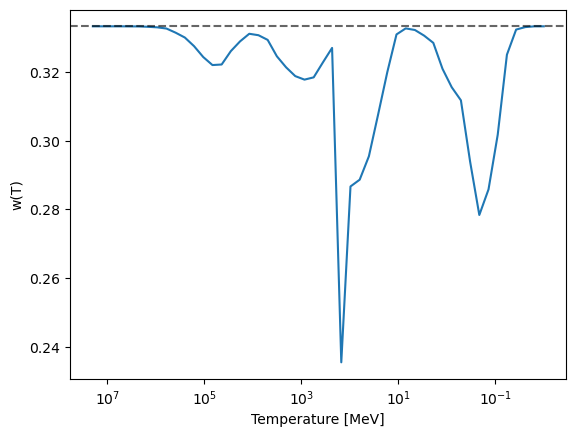

In [41]:
plt.plot(T, w_EM(T))

plt.xscale('log')
plt.gca().invert_xaxis()
plt.ylabel('w(T)')
plt.xlabel('Temperature [MeV]')

plt.axhline(1/3, linestyle='dashed', color='black', alpha=0.6)